
# Teleport a Qubit Across NZ (Auckland ↔ Christchurch)
Conceptual Quantum Teleportation Architecture Activity (Group Work) 
by Benjelyn, Roxanne, Albert, Earl

Show a simple **Qiskit** demo of quantum teleportation.

Key idea:
- Auckland (Alice) has qubit |psi> Christchurch (Bob) must get same |psi>
- The qubit **does not travel** like a package.
- use:
  1) **entanglement** (shared quantum link),
  2) **2 classical bits** (normal internet message),
  3) **Bob correction** (X / Z),
- Then Bob ends with the same state **|ψ>**.



## 1) Architecture (this is the main point)

### Roles
- **Auckland Lab (Alice)**: has unknown qubit **|ψ>** (the "message")
- **Christchurch Lab (Bob)**: will receive the final qubit state
- **Quantum Link / Network**: used only to distribute **entanglement**
- **Classical Link (internet/5G/fibre)**: used to send **2 bits** after measurement

### Architecture diagram (simple)
```text
(Auckland Lab)                                         (Christchurch Lab)
   Alice                                                     Bob
   ┌───────────────┐         Quantum channel (fibre/free-space)    ┌───────────────┐
   │ Unknown qubit  │  |ψ>   send entangled half (EPR photon/qubit) │ Entangled qubit│
   └───────┬───────┘──────────────────────────────────────────────▶└───────┬───────┘
           │                                                                  │
           │ Bell measurement on (|ψ> + Alice-half of EPR)                     │
           ▼                                                                  ▼
     2 classical bits (b1,b2)  ─────── normal internet/5G ───────▶     Apply corrections:
                                                                      if b2=1 → X
                                                                      if b1=1 → Z
                                                                      Final qubit = |ψ>
```

### What travels?
- **Entanglement half** travels first (quantum channel).
- **Two classical bits** travel next (normal internet).
- The original **|ψ> is destroyed** at Alice during measurement (no cloning).



## 2) Teleportation steps (super simple)

1. **Prepare unknown qubit |ψ>** (Alice has it)
2. **Create entangled pair** (EPR pair). One qubit stays with Alice, one goes to Bob.
3. **Alice does Bell measurement** on her 2 qubits (|ψ> + her entangled qubit)
4. Alice gets **2 classical bits** (example: 00, 01, 10, 11)
5. Alice sends those bits to Bob using **normal internet**
6. Bob applies correction:
   - if second bit = 1 → apply **X** (bit flip)
   - if first bit  = 1 → apply **Z** (phase flip)
7. Bob now holds **the same state |ψ>**

That is the full architecture logic.



## 3) Qiskit demo will:
- Create a teleportation circuit (3 qubits)
  - q0 = Alice's unknown qubit |ψ>
  - q1 = Alice's entangled half
  - q2 = Bob's entangled half
- Run on simulator
- Check Bob's final state


In [1]:
# Import Qiskit tools
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np


In [2]:
# --- Build teleportation circuit (architecture in code) ---

# 3 qubits:
# q0 = Alice unknown qubit |psi>
# q1 = entangled pair qubit on Alice side
# q2 = entangled pair qubit on Bob side
q = QuantumRegister(3, "q")

# 2 classical bits from Alice measurement
c_alice = ClassicalRegister(2, "alice_bits")

# optional: 1 classical bit to read Bob at end (for measurement demo)
c_bob = ClassicalRegister(1, "bob_bit")

qc = QuantumCircuit(q, c_alice, c_bob) #Create the circuit container

# ---  *****  Step A: Prepare Alice unknown state |ψ> (|psi>) on q0 ---
# H (Hadamard) makes superposition. It changes |0> into |+>
# You can change this later to any state.
qc.h(q[0])  # now q0 is in |+>

# --- ***** Step B: Create entanglement pair (EPR pair) between q1 and q2 ---
# This is the "quantum link distributed entanglement" part.
# H on q[1] makes it half/half
# CX links them → now q[1] and q[2] become entangled ; q[2] is Bob’s entangled half (Christchurch)
qc.h(q[1])
qc.cx(q[1], q[2])  # q1-q2 are now entangled (EPR pair)

# ---  ***** Step C: Alice Bell measurement on (q0,q1) -special measurement ---
qc.cx(q[0], q[1]) #Alice is doing a special “mix + check” operation on her 2 qubits
qc.h(q[0])

# Measure Alice qubits -> produce 2 classical bits
qc.measure(q[0], c_alice[0])   # first bit
qc.measure(q[1], c_alice[1])   # second bit

# ---  ***** Step D: Bob correction (Christchurch fixing step) using classical bits ---
# In real life, Alice sends those 2 bits over internet.
# Bob waits the 2 bits from Alice.
# Then Bob does:
# If Alice second bit = 1 → Bob apply X (bit flip)
# If Alice first bit = 1 → Bob apply Z (phase flip)
# After this correction, Bob’s qubit becomes |ψ>
#
# We'll apply corrections for the 4 possible outcomes:
# 00 -> do nothing
# 01 -> X
# 10 -> Z
# 11 -> X then Z
# old
# helper: apply X when outcome is 1 or 3
# qc.x(q[2]).c_if(c_alice, 1)
# qc.x(q[2]).c_if(c_alice, 3)

# helper: apply Z when outcome is 2 or 3
# qc.z(q[2]).c_if(c_alice, 2)
# qc.z(q[2]).c_if(c_alice, 3)


# --- Step D: Bob correction using new control-flow style ---

# If Alice second bit == 1 → apply X
with qc.if_test((c_alice[1], 1)):
    qc.x(q[2])

# If Alice first bit == 1 → apply Z
with qc.if_test((c_alice[0], 1)):
    qc.z(q[2])

    
# --- (Optional) Measure Bob for histogram demo ---
qc.measure(q[2], c_bob[0])

qc



### Quick note about correction logic
In real teleportation, Bob receives two bits: (b1, b2).  
Then Bob does:
- if b2 = 1 → X  
- if b1 = 1 → Z  

In this Qiskit demo, the two bits are combined into one 2-bit number (00=0, 01=1, 10=2, 11=3).  
So we apply X for outcomes 1 and 3, and Z for outcomes 2 and 3.


In [3]:
# Run circuit on simulator (shot-based)
sim = AerSimulator()
job = sim.run(qc, shots=2048)
result = job.result()
counts = result.get_counts(qc)
counts


{'0 01': 284,
 '0 00': 246,
 '0 11': 257,
 '1 00': 254,
 '1 11': 273,
 '0 10': 252,
 '1 01': 237,
 '1 10': 245}

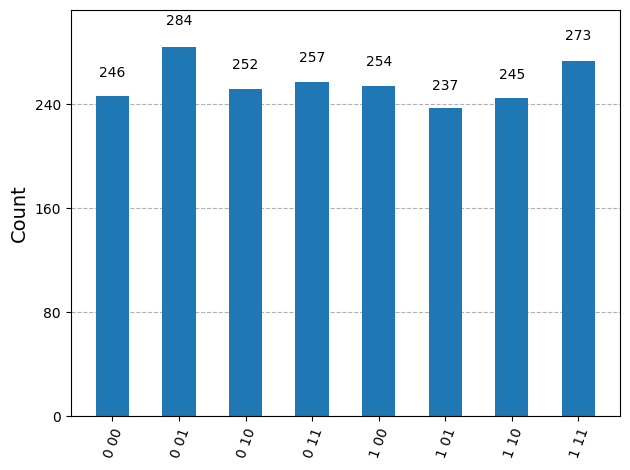

In [4]:
# Show histogram, Bob's measured output distribution
plot_histogram(counts)



## 4) Check fidelity (state match) using statevector (clean proof)

Measurement collapses the circuit, so for **fidelity proof** we do a version of the circuit **without final measurement**,  
and we compare Bob's qubit state to the expected |ψ>.

This is closer to "proof" that teleportation worked in simulation.


In [5]:
# build a version of the circuit without final measurement.
# Why? to analyze the quantum state directly
# using statevector (this shows the exact mathematical state).

q = QuantumRegister(3, "q")          # Create 3 qubits (same teleportation setup)
qc_sv = QuantumCircuit(q)            # Create a new clean circuit

# Step 1: Prepare the state |psi> on q0.
# For this example, we choose |+> state again.
# Applying H to |0> makes |+>.
qc_sv.h(q[0])

# Step 2: Create entangled pair between q1 and q2.
# This represents the quantum link between Auckland and Christchurch.
qc_sv.h(q[1])
qc_sv.cx(q[1], q[2])

# Normally, the next step would be Bell measurement.
# But here we do NOT measure.
# Why?
# Because measurement collapses the state,
# and statevector simulation works best without collapse.

# Important note:
# Simply removing measurement does NOT automatically prove teleportation,
# because Bob’s correction depends on Alice’s measurement results.

# In real teleportation:
# 1) Alice measures
# 2) Alice sends 2 classical bits
# 3) Bob applies correction (X and/or Z)

# But inside statevector simulation,
# classical conditions and measurement collapse
# make things more complicated.

# So instead of pure mathematical proof,
# we use a practical approach:
# We run many shots later and compare statistics.

# For example:
# If the teleported state is |+>,
# then measuring in Z basis should give 50% 0 and 50% 1.
# And measuring in X basis should give nearly 100% correct result.

print("If teleportation works, Bob behaves like original |+> state.")
print("In Z basis → 50/50 result.")
print("In X basis → almost always 0.")


If teleportation works, Bob behaves like original |+> state.
In Z basis → 50/50 result.
In X basis → almost always 0.


In [6]:
# Test Bob in X-basis.
# Why X-basis?
# Because our original state is |+>.
# If teleportation works correctly,
# measuring |+> in X-basis should always give 0.

# Create 3 qubits again (same teleportation setup)
q = QuantumRegister(3, "q")

# Create classical bits:
# 2 bits for Alice measurement
# 1 bit to measure Bob at the end
c_alice = ClassicalRegister(2, "alice_bits")
c_bob = ClassicalRegister(1, "bob_bit")

# Build the circuit
qc_x = QuantumCircuit(q, c_alice, c_bob)

# --------------------------------
# Step 1: Prepare the state |+>
# --------------------------------
# Apply Hadamard to q0.
# This creates |+> state.
qc_x.h(q[0])

# --------------------------------
# Step 2: Create entanglement
# --------------------------------
# This simulates the quantum link between Auckland and Christchurch.
qc_x.h(q[1])
qc_x.cx(q[1], q[2])

# --------------------------------
# Step 3: Alice performs Bell measurement
# --------------------------------
qc_x.cx(q[0], q[1])
qc_x.h(q[0])

# Alice measures her two qubits.
# These become the 2 classical bits she sends to Bob.
qc_x.measure(q[0], c_alice[0])
qc_x.measure(q[1], c_alice[1])

# --------------------------------
# Step 4: Bob applies correction
# --------------------------------
# After Alice sends the 2 bits,
# Bob checks them and applies corrections.

# If Alice second bit is 1 → Bob applies X
with qc_x.if_test((c_alice[1], 1)):
    qc_x.x(q[2])

# If Alice first bit is 1 → Bob applies Z
with qc_x.if_test((c_alice[0], 1)):
    qc_x.z(q[2])

# --------------------------------
# Step 5: Measure Bob in X-basis
# --------------------------------
# Measuring in X-basis means:
# Apply Hadamard first,
# then measure in normal Z-basis.
qc_x.h(q[2])
qc_x.measure(q[2], c_bob[0])

# --------------------------------
# Step 6: Run simulation
# --------------------------------
sim = AerSimulator()
res = sim.run(qc_x, shots=2048).result()
counts_x = res.get_counts(qc_x)

counts_x

{'0 00': 520, '0 10': 508, '0 01': 510, '0 11': 510}


### Reading the X-basis test
If teleported state is really **|+>**, then measuring in **X-basis** should give **almost all 0**.  



## 5) Practical challenges (real NZ link)

Even if the math is correct, real system has problems:

### Loss
- Photons can be lost in fibre (distance, connectors, bends).
- Free-space links can be blocked by weather, vibration, alignment.

### Decoherence / noise
- Entanglement quality drops because hardware is not perfect.
- Detectors have errors (dark counts).

### Timing & synchronization
- match entangled detection events using tight time windows.
- Need good clock sync and time-stamping.

### Scaling
- For longer distance,  need **repeaters** (future tech) to extend entanglement.
- Also need better sources, better detectors, and error handling.



## 6) Final takeaway 
**Teleportation = entanglement (quantum link) + 2 classical bits (internet) + Bob correction (X/Z) → Bob gets |ψ>.**
